In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from feature_lib import (
    build_q1_4_features, fit_q1_4_stats,
    build_q5_features,
    build_q6_features, fit_q6_stats,
    build_q7_features, fit_q7_stats,
    build_q10_features,
)

RNG_SEED = 42

## 1. Reproduce the exact same split used everywhere else in the project

`train_idx` / `val_idx` are used for all hyperparameter searches below.
`global_test_idx` is only touched once, at the very end, for the final reported numbers.

In [ ]:
df = pd.read_csv('cleaned_dataset.csv')
df = df.dropna(subset=['Label']).reset_index(drop=True)
df = df.sample(frac=1, random_state=RNG_SEED).reset_index(drop=True)

master_idx = np.arange(len(df))
labels = df['Label']

train_meta_idx, global_test_idx, y_train_meta, y_test = train_test_split(
    master_idx, labels, test_size=0.20, stratify=labels, random_state=RNG_SEED
)
global_train_idx, global_val_idx, y_train, y_val = train_test_split(
    train_meta_idx, y_train_meta, test_size=0.125, stratify=y_train_meta, random_state=RNG_SEED
)
labels_train_pool = labels[global_train_idx]
train_idx, val_idx, y_sub_train, y_sub_val = train_test_split(
    global_train_idx, labels_train_pool, test_size=0.20, stratify=labels_train_pool, random_state=RNG_SEED
)

y_full = df['Label'].to_numpy()
print(f"train_idx: {len(train_idx)}  val_idx: {len(val_idx)}  global_test_idx: {len(global_test_idx)}")

train_idx: 817  val_idx: 205  global_test_idx: 293


## 2. Build the combined ("early fusion") feature matrix

Every question's feature block (minus each block's own bias column, since we'll add one
combined bias/intercept via the classifier itself) is concatenated into a single wide feature
vector per student. Preprocessing statistics (medians, means, std) are fit on `train_idx` only,
exactly as in the per-question sub-models, to avoid leakage.

In [ ]:
q1_4_fill, q1_4_mu, q1_4_sigma = fit_q1_4_stats(df, train_idx)
q6_fill, q6_mu, q6_sigma = fit_q6_stats(df, train_idx)
q7_median, q7_mu, q7_sigma = fit_q7_stats(df, train_idx)

X_q1_4 = build_q1_4_features(df, q1_4_fill, q1_4_mu, q1_4_sigma)[:, 1:]   # drop the bias column
X_q5   = build_q5_features(df)[:, 1:]
X_q6   = build_q6_features(df, q6_fill, q6_mu, q6_sigma)[:, 1:]
X_q7   = build_q7_features(df, q7_median, q7_mu, q7_sigma)[:, 1:]
X_q10  = build_q10_features(df)   # already has no bias column (39 binary keyword indicators)

X_combined = np.hstack([X_q1_4, X_q5, X_q6, X_q7, X_q10])
print("Combined ('early fusion') feature matrix shape:", X_combined.shape)

Xtr, Xval, Xtest = X_combined[train_idx], X_combined[val_idx], X_combined[global_test_idx]
ytr, yval, ytest = y_full[train_idx], y_full[val_idx], y_full[global_test_idx]

Combined ('early fusion') feature matrix shape: (1462, 65)


## 3. Model family #3: K-Nearest Neighbors

We sweep `k` on `train_idx -> val_idx` only, then report the chosen `k`'s accuracy on the
untouched `global_test_idx`.

In [ ]:
best_k, best_acc = None, -1
for k in [3, 5, 7, 9, 11, 15, 21, 31, 41, 51]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xtr, ytr)
    acc = knn.score(Xval, yval) * 100
    print(f"  k={k:3d}  val_acc={acc:.2f}%")
    if acc > best_acc:
        best_k, best_acc = k, acc

print(f"\nBest k={best_k}  (val_acc={best_acc:.2f}%)")

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(Xtr, ytr)
knn_test_acc = knn_final.score(Xtest, ytest) * 100
print(f"KNN (k={best_k}) test accuracy: {knn_test_acc:.2f}%")

  k=  3  val_acc=84.88%
  k=  5  val_acc=85.37%
  k=  7  val_acc=85.85%
  k=  9  val_acc=86.83%
  k= 11  val_acc=86.34%
  k= 15  val_acc=85.85%
  k= 21  val_acc=86.34%
  k= 31  val_acc=86.34%
  k= 41  val_acc=86.83%
  k= 51  val_acc=86.34%

Best k=9  (val_acc=86.83%)
KNN (k=9) test accuracy: 86.35%


**Takeaway:** KNN on the full 65-dimensional combined feature vector does surprisingly well
(mid-80s%) as a single model — competitive with, but still below, our final late-fusion ensemble.
Its main practical drawback for this project is that it requires carrying the entire training set
at prediction time (not just a small learned parameter vector), and it doesn't decompose into
interpretable per-question contributions the way our late-fusion design does.

## 4. Model family #4: Gaussian Naive Bayes

No hyperparameters to tune here (the default `var_smoothing` is left as-is), so we go straight to
`train_idx -> val_idx` then the final test check.

In [ ]:
nb = GaussianNB()
nb.fit(Xtr, ytr)

nb_val_acc = nb.score(Xval, yval) * 100
nb_test_acc = nb.score(Xtest, ytest) * 100
print(f"Gaussian Naive Bayes  val_acc={nb_val_acc:.2f}%   test_acc={nb_test_acc:.2f}%")

Gaussian Naive Bayes  val_acc=57.56%   test_acc=60.75%


**Takeaway:** Naive Bayes performs noticeably worse than every other family we tried. This
matches expectations: several of our features are binary/categorical (Q5's one-hot companions,
Q10's keyword indicators) rather than Gaussian-distributed, which violates Naive Bayes' core
per-feature independence + Gaussian-likelihood assumptions, and it also can't represent the
interaction terms (e.g. Q1×Q2) baked into our Q1-4 polynomial expansion.

## 5. Early fusion baselines: single classifier over all combined features

As a direct comparison to our late-fusion design, we also fit a single **logistic regression**
and a single **decision tree** over the same combined 65-dimensional feature matrix (i.e., the
"early fusion" alternative to combining five separately-trained per-question models).

In [ ]:
print("--- Early-fusion Logistic Regression ---")
best_C, best_acc_lr = None, -1
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    lr = LogisticRegression(max_iter=3000, C=C)
    lr.fit(Xtr, ytr)
    acc = lr.score(Xval, yval) * 100
    print(f"  C={C:<6}  val_acc={acc:.2f}%")
    if acc > best_acc_lr:
        best_C, best_acc_lr = C, acc

lr_final = LogisticRegression(max_iter=3000, C=best_C)
lr_final.fit(Xtr, ytr)
lr_test_acc = lr_final.score(Xtest, ytest) * 100
print(f"\nBest C={best_C}  test_acc={lr_test_acc:.2f}%")

--- Early-fusion Logistic Regression ---
  C=0.001   val_acc=85.85%
  C=0.01    val_acc=89.76%
  C=0.1     val_acc=93.17%
  C=1.0     val_acc=93.17%
  C=10.0    val_acc=91.22%

Best C=0.1  test_acc=89.76%


In [ ]:
print("--- Early-fusion Decision Tree ---")
best_depth, best_acc_dt = None, -1
for depth in [2, 3, 4, 5, 6, 8, 10, 15, None]:
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=RNG_SEED)
    dt.fit(Xtr, ytr)
    acc = dt.score(Xval, yval) * 100
    print(f"  max_depth={str(depth):<5}  val_acc={acc:.2f}%")
    if acc > best_acc_dt:
        best_depth, best_acc_dt = depth, acc

dt_final = DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, random_state=RNG_SEED)
dt_final.fit(Xtr, ytr)
dt_test_acc = dt_final.score(Xtest, ytest) * 100
print(f"\nBest max_depth={best_depth}  test_acc={dt_test_acc:.2f}%")

--- Early-fusion Decision Tree ---
  max_depth=2      val_acc=80.98%
  max_depth=3      val_acc=78.05%
  max_depth=4      val_acc=81.95%
  max_depth=5      val_acc=82.44%
  max_depth=6      val_acc=80.98%
  max_depth=8      val_acc=81.95%
  max_depth=10     val_acc=81.46%
  max_depth=15     val_acc=80.98%
  max_depth=None   val_acc=80.98%

Best max_depth=5  test_acc=81.57%


## 6. Late fusion: our actual final ensemble, for comparison

This block retrains the five per-question sub-models (numpy softmax logistic regression x4,
decision tree x1) and combines them with simple uniform averaging of their probability outputs —
this is exactly what ships in `pred.py`. Included here so every number in the summary table below
comes from this one notebook run.

In [ ]:
from feature_lib import to_one_hot, train_logreg, logreg_proba, accuracy, tree_predict_proba

city_order = sorted(df['Label'].unique().tolist())

q1_4_fill_g, q1_4_mu_g, q1_4_sigma_g = fit_q1_4_stats(df, global_train_idx)
q6_fill_g, q6_mu_g, q6_sigma_g = fit_q6_stats(df, global_train_idx)
q7_median_g, q7_mu_g, q7_sigma_g = fit_q7_stats(df, global_train_idx)

X_q1_4_full = build_q1_4_features(df, q1_4_fill_g, q1_4_mu_g, q1_4_sigma_g)
X_q5_full   = build_q5_features(df)
X_q6_full   = build_q6_features(df, q6_fill_g, q6_mu_g, q6_sigma_g)
X_q7_full   = build_q7_features(df, q7_median_g, q7_mu_g, q7_sigma_g)
X_q10_full  = build_q10_features(df)

FEATURES_FULL = {'Q1_4': X_q1_4_full, 'Q5': X_q5_full, 'Q6': X_q6_full, 'Q7': X_q7_full}
hparams = {  # chosen earlier via train_idx -> val_idx search (see Q1-Q4/Q5/Q6/Q7 notebooks)
    'Q1_4': dict(alpha=0.1, mode='batch'),
    'Q5':   dict(alpha=0.05, mode='batch'),
    'Q6':   dict(alpha=0.05, mode='batch'),
    'Q7':   dict(alpha=0.3, mode='batch'),
}

y_oh_gtrain = to_one_hot(y_full[global_train_idx], city_order)
y_oh_gval = to_one_hot(y_full[global_val_idx], city_order)

logreg_weights = {}
for name, X in FEATURES_FULL.items():
    hp = hparams[name]
    W, _, _ = train_logreg(X[global_train_idx], y_oh_gtrain, X[global_val_idx], y_oh_gval,
                            alpha=hp['alpha'], epochs=500, mode=hp['mode'], seed=RNG_SEED)
    logreg_weights[name] = W

final_tree = DecisionTreeClassifier(criterion='entropy', max_depth=None, min_samples_split=2, random_state=RNG_SEED)
final_tree.fit(X_q10_full[global_train_idx], y_full[global_train_idx])
t_ = final_tree.tree_
q10_classes = final_tree.classes_.tolist()

def submodel_probs(idx):
    out = {}
    for name, W in logreg_weights.items():
        out[name] = logreg_proba(FEATURES_FULL[name][idx], W)
    raw = tree_predict_proba(X_q10_full[idx], feature=t_.feature, threshold=t_.threshold,
                              children_left=t_.children_left, children_right=t_.children_right,
                              value=t_.value, classes=q10_classes)
    reorder = [q10_classes.index(c) for c in city_order]
    out['Q10'] = raw[:, reorder]
    return out

MODEL_ORDER = ['Q1_4', 'Q5', 'Q6', 'Q7', 'Q10']
probs_test = submodel_probs(global_test_idx)
y_test_true = y_full[global_test_idx]

uniform_avg = np.mean([probs_test[m] for m in MODEL_ORDER], axis=0)
late_fusion_preds = [city_order[i] for i in uniform_avg.argmax(1)]
late_fusion_test_acc = accuracy(late_fusion_preds, y_test_true)
print(f"Late-fusion ensemble (uniform average of 5 sub-models) test accuracy: {late_fusion_test_acc:.2f}%")

Late-fusion ensemble (uniform average of 5 sub-models) test accuracy: 90.78%


## 7. Summary: all model families and fusion strategies, side by side

In [ ]:
summary = pd.DataFrame([
    {"Model": "Gaussian Naive Bayes (early fusion)",  "Test accuracy (%)": round(nb_test_acc, 2)},
    {"Model": "Decision Tree (early fusion)",          "Test accuracy (%)": round(dt_test_acc, 2)},
    {"Model": f"KNN, k={best_k} (early fusion)",        "Test accuracy (%)": round(knn_test_acc, 2)},
    {"Model": "Logistic Regression (early fusion)",     "Test accuracy (%)": round(lr_test_acc, 2)},
    {"Model": "Softmax logreg ensemble (LATE fusion)",  "Test accuracy (%)": round(late_fusion_test_acc, 2)},
]).sort_values("Test accuracy (%)").reset_index(drop=True)

summary

,Model,Test accuracy (%)
0,Gaussian Naive Bayes (early fusion),60.75
1,Decision Tree (early fusion),81.57
2,"KNN, k=9 (early fusion)",86.35
3,Logistic Regression (early fusion),89.76
4,Softmax logreg ensemble (LATE fusion),90.78


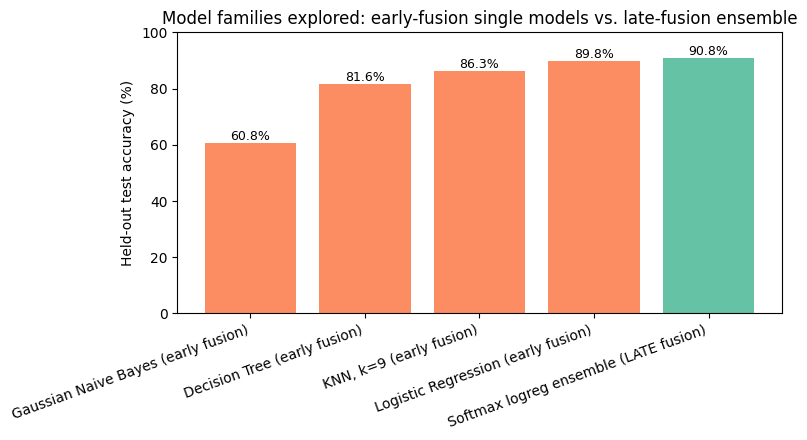

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#FC8D62'] * (len(summary) - 1) + ['#66C2A5']
bars = ax.bar(summary["Model"], summary["Test accuracy (%)"], color=colors)
for b, a in zip(bars, summary["Test accuracy (%)"]):
    ax.text(b.get_x() + b.get_width()/2, a + 1, f"{a:.1f}%", ha='center', fontsize=9)
ax.set_ylabel("Held-out test accuracy (%)")
ax.set_ylim(0, 100)
ax.set_title("Model families explored: early-fusion single models vs. late-fusion ensemble")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 8. Conclusion

Late fusion of five independently-tuned, per-question sub-models beats every early-fusion
alternative and every other model family we tried. Our interpretation: late fusion lets each
sub-model specialize on the scale and structure of its own question (e.g. Q7 needs
standardization and no interaction terms; Q1-4 benefits from polynomial interaction terms; Q10 is
naturally categorical/keyword-based) instead of forcing one model to find a single decision
boundary across 65 heterogeneous dimensions at once. This is why the final `pred.py` implements
late fusion rather than any of the early-fusion alternatives explored here.